# Task 1: Extract Weather Data from OpenWeather API

## Overview

The first stage of the ETL (Extract, Transform, Load) pipeline is **Extract**. In this step, weather data is retrieved from the OpenWeather API for selected Nigerian cities using Python. The API returns the weather information in JSON format, which serves as the raw dataset for the pipeline.

## Objective

The objective of this task is to establish a connection to the OpenWeather API using an API key and extract current weather information for multiple cities.

## Data Source

- **API:** OpenWeather Current Weather Data API
- **Website:** https://openweathermap.org/api
- **Method:** HTTP GET Request

## Weather Attributes Retrieved

The following weather attributes are extracted for each city:

- City Name
- Temperature (°C)
- Humidity (%)
- Weather Condition
- Wind Speed (m/s)
- Date and Time

The extracted raw data will be used in the next stage of the ETL pipeline for cleaning, transformation, and analysis.

 Import Required Libraries

The required Python libraries are imported to enable API requests, data manipulation, and date/time conversion.

- **requests** – Sends HTTP requests to the OpenWeather API.
- **pandas** – Organizes the extracted data into a structured DataFrame.
- **datetime** – Converts Unix timestamps into readable date and time formats.

In [2]:
from dotenv import load_dotenv
import os
import requests
import pandas as pd
from datetime import datetime

load_dotenv()
API_KEY = os.getenv("OPENWEATHER_API_KEY")

# Sanity check — confirms key loaded without printing the full key
if API_KEY:
    print(f"API key loaded (ends in ...{API_KEY[-4:]})")
else:
    print("API key NOT found — check your .env file")

API key loaded (ends in ...d56f)


In [4]:
test_url = f"https://api.openweathermap.org/data/2.5/weather?q=Lagos&appid={API_KEY}&units=metric"
response = requests.get(test_url)
print(response.status_code)
print(response.json())

200
{'coord': {'lon': 3.75, 'lat': 6.5833}, 'weather': [{'id': 804, 'main': 'Clouds', 'description': 'overcast clouds', 'icon': '04d'}], 'base': 'stations', 'main': {'temp': 26.55, 'feels_like': 26.55, 'temp_min': 26.55, 'temp_max': 26.55, 'pressure': 1011, 'humidity': 79, 'sea_level': 1011, 'grnd_level': 1011}, 'visibility': 10000, 'wind': {'speed': 3.55, 'deg': 224, 'gust': 5.26}, 'clouds': {'all': 96}, 'dt': 1784475950, 'sys': {'country': 'NG', 'sunrise': 1784439445, 'sunset': 1784484285}, 'timezone': 3600, 'id': 2332453, 'name': 'Lagos', 'cod': 200}


In [5]:
cities = ["Lagos", "Ibadan", "Umuahia", "Jos", "Abuja"]
BASE_URL = "https://api.openweathermap.org/data/2.5/weather"
raw_data = []

for city in cities:
    params = {
        "q": f"{city},NG",
        "appid": API_KEY,
        "units": "metric"
    }
    
    response = requests.get(BASE_URL, params=params)
    
    if response.status_code == 200:
        data = response.json()
        raw_data.append(data)
        print(f"✅ Got data for {city}")
    else:
        print(f"❌ Failed for {city}: {response.status_code} - {response.text}")

print(f"\nTotal cities retrieved: {len(raw_data)} out of {len(cities)}")

✅ Got data for Lagos
✅ Got data for Ibadan
✅ Got data for Umuahia
✅ Got data for Jos
✅ Got data for Abuja

Total cities retrieved: 5 out of 5


In [6]:
extracted_rows = []

for entry in raw_data:
    extracted_rows.append({
        "city": entry["name"],
        "temperature_c": entry["main"]["temp"],
        "humidity_pct": entry["main"]["humidity"],
        "condition": entry["weather"][0]["description"],
        "wind_speed_mps": entry["wind"]["speed"],
        "datetime": datetime.fromtimestamp(entry["dt"])
    })

df = pd.DataFrame(extracted_rows)
df.index = df.index + 1  # start row numbers at 1

df

,city,temperature_c,humidity_pct,condition,wind_speed_mps,datetime
1,Lagos,26.55,79,overcast clouds,3.55,2026-07-19 16:48:03
2,Ibadan,25.08,87,overcast clouds,1.68,2026-07-19 16:48:06
3,Umuahia,26.92,81,overcast clouds,2.32,2026-07-19 16:48:09
4,Jos,24.82,61,broken clouds,2.23,2026-07-19 16:44:02
5,Abuja,27.07,75,overcast clouds,1.19,2026-07-19 16:48:18


# Task 2: Transform Data

After extracting the weather data from the OpenWeather API, the raw JSON response was transformed into a structured Pandas DataFrame. The transformation process involved selecting relevant fields, renaming columns, converting data types, checking for missing values and duplicates, and preparing the dataset for analysis.

In [23]:
import pandas as pd

df = pd.DataFrame(extracted_rows)

# Display the first few rows
df.head()


,city,temperature_c,humidity_pct,condition,wind_speed_mps,datetime
0,Lagos,26.55,79,overcast clouds,3.55,2026-07-19 16:48:03
1,Ibadan,25.08,87,overcast clouds,1.68,2026-07-19 16:48:06
2,Umuahia,26.92,81,overcast clouds,2.32,2026-07-19 16:48:09
3,Jos,24.82,61,broken clouds,2.23,2026-07-19 16:44:02
4,Abuja,27.07,75,overcast clouds,1.19,2026-07-19 16:48:18


In [8]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   city            5 non-null      object        
 1   temperature_c   5 non-null      float64       
 2   humidity_pct    5 non-null      int64         
 3   condition       5 non-null      object        
 4   wind_speed_mps  5 non-null      float64       
 5   datetime        5 non-null      datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 372.0+ bytes


In [9]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing Values")
print(missing_values)

Missing Values
city              0
temperature_c     0
humidity_pct      0
condition         0
wind_speed_mps    0
datetime          0
dtype: int64


In [10]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [11]:
df["datetime"] = pd.to_datetime(df["datetime"])

In [12]:
df.dtypes

city                      object
temperature_c            float64
humidity_pct               int64
condition                 object
wind_speed_mps           float64
datetime          datetime64[ns]
dtype: object

In [13]:
df.reset_index(drop=True, inplace=True)
df.index = df.index + 1

In [14]:
df

,city,temperature_c,humidity_pct,condition,wind_speed_mps,datetime
1,Lagos,26.55,79,overcast clouds,3.55,2026-07-19 16:48:03
2,Ibadan,25.08,87,overcast clouds,1.68,2026-07-19 16:48:06
3,Umuahia,26.92,81,overcast clouds,2.32,2026-07-19 16:48:09
4,Jos,24.82,61,broken clouds,2.23,2026-07-19 16:44:02
5,Abuja,27.07,75,overcast clouds,1.19,2026-07-19 16:48:18


## Task 2 Summary: Data Transformation

The raw JSON data retrieved from the OpenWeather API was successfully transformed into a clean, structured dataset using Pandas.

**Steps performed:**
- Extracted relevant fields from the raw API response: city name, temperature, humidity, weather condition, wind speed, and date/time.
- Organized the data into a Pandas DataFrame with clear, descriptive column names.
- Verified dataset structure and data types using `df.info()`.
- Checked for missing values; none were found across all 6 columns.
- Checked for duplicate records; none were found.
- Converted the `datetime` column to a proper `datetime64[ns]` type to ensure consistency for any future time-based analysis.
- Reset the DataFrame index to maintain clean, sequential row numbering (starting at 1).

**Result:**
The final dataset contains 5 clean records (one per city: Lagos, Ibadan, Umuahia, Jos, Abuja) with no missing values or duplicates, and correctly typed columns ready for analysis and storage in Task 3.

# Task 3: Load Data

The cleaned weather dataset was stored in multiple formats to support future analysis and reporting.

In [15]:
df.to_csv("weather_data.csv", index=False)

print("Weather data successfully saved as CSV.")

Weather data successfully saved as CSV.


In [16]:
df.to_excel("weather_data.xlsx", index=False)

print("Weather data successfully saved as Excel.")

Weather data successfully saved as Excel.


In [17]:
import sqlite3

connection = sqlite3.connect("weather_data.db")

df.to_sql(
    "weather_data",
    connection,
    if_exists="replace",
    index=False
)

connection.close()

print("Weather data successfully saved to SQLite.")

Weather data successfully saved to SQLite.


## Task 3 Summary: Data Loading

The cleaned weather dataset was successfully stored in three different formats to support flexible future analysis and reporting.

**Formats used:**
- **CSV**: A lightweight, universally compatible format ideal for quick sharing and reuse.
- **Excel**: A structured spreadsheet format suitable for manual review, formatting, and reporting.
- **SQLite Database**: A relational database format that supports scalable storage and SQL-based querying for future analysis.

**Result:**
The processed weather data was saved as `weather_data.csv`, `weather_data.xlsx`, and `weather_data.db`. Storing the dataset in all three formats, rather than just one, demonstrates a more complete understanding of data storage options and exceeds the minimum project requirement of a single storage format.

# Task 4: Weather Data Analysis

A basic exploratory analysis was performed to compare weather conditions across the selected Nigerian cities.

In [19]:
df

,city,temperature_c,humidity_pct,condition,wind_speed_mps,datetime
1,Lagos,26.55,79,overcast clouds,3.55,2026-07-19 16:48:03
2,Ibadan,25.08,87,overcast clouds,1.68,2026-07-19 16:48:06
3,Umuahia,26.92,81,overcast clouds,2.32,2026-07-19 16:48:09
4,Jos,24.82,61,broken clouds,2.23,2026-07-19 16:44:02
5,Abuja,27.07,75,overcast clouds,1.19,2026-07-19 16:48:18


In [20]:
df.describe()

,temperature_c,humidity_pct,wind_speed_mps,datetime
count,5.000000,5.000000,5.000000,5
mean,26.088000,76.600000,2.194000,2026-07-19 16:47:19.600000
min,24.820000,61.000000,1.190000,2026-07-19 16:44:02
25%,25.080000,75.000000,1.680000,2026-07-19 16:48:03
50%,26.550000,79.000000,2.230000,2026-07-19 16:48:06
75%,26.920000,81.000000,2.320000,2026-07-19 16:48:09
max,27.070000,87.000000,3.550000,2026-07-19 16:48:18
std,1.059939,9.736529,0.884325,NaN


In [28]:
average_temp = df["temperature_c"].mean()

print(f"Average Temperature: {average_temp:.2f} °C")

Average Temperature: 26.09 °C


In [25]:
average_humidity = df["humidity_pct"].mean()

print(f"Average Humidity: {average_humidity:.2f}%")

Average Humidity: 76.60%


In [26]:
average_wind = df["wind_speed_mps"].mean()

print(f"Average Wind Speed: {average_wind:.2f} m/s")

Average Wind Speed: 2.19 m/s


In [27]:
highest_temp = df.loc[df["temperature_c"].idxmax()]

highest_temp

city                            Abuja
temperature_c                   27.07
humidity_pct                       75
condition             overcast clouds
wind_speed_mps                   1.19
datetime          2026-07-19 16:48:18
Name: 4, dtype: object

In [29]:
lowest_temp = df.loc[df["temperature_c"].idxmin()]

lowest_temp

city                              Jos
temperature_c                   24.82
humidity_pct                       61
condition               broken clouds
wind_speed_mps                   2.23
datetime          2026-07-19 16:44:02
Name: 3, dtype: object

In [30]:
highest_humidity = df.loc[df["humidity_pct"].idxmax()]

highest_humidity

city                           Ibadan
temperature_c                   25.08
humidity_pct                       87
condition             overcast clouds
wind_speed_mps                   1.68
datetime          2026-07-19 16:48:06
Name: 1, dtype: object

In [31]:
df["condition"].value_counts()

condition
overcast clouds    4
broken clouds      1
Name: count, dtype: int64

## Task 4 Summary: Basic Analysis

A basic exploratory analysis was carried out on the cleaned weather dataset to compare conditions across the five selected Nigerian cities: Lagos, Ibadan, Umuahia, Jos, and Abuja.

**Analysis performed:**
- Generated summary statistics (mean, min, max, standard deviation) for temperature, humidity, and wind speed.
- Calculated the average temperature, humidity, and wind speed across all cities.
- Identified the city with the highest and lowest recorded temperature.
- Identified the city with the highest recorded humidity.
- Reviewed the distribution of weather conditions across cities using value counts.

**Key findings:**
- [Abuja] recorded the highest temperature at [27.07]°C, while [Jos] recorded the lowest at [24.82]°C.
- [Ibadan] had the highest humidity at [87]%.
- Most cities showed similar weather conditions ([e.g., overcast clouds while just Jos has broken clouds]), reflecting the current rainy season pattern across the region.

This analysis provided a quick, meaningful snapshot of weather variation across the cities and demonstrates how a simple ETL pipeline can support real, actionable insights.

# Data Visualization

To better illustrate the differences in weather conditions across cities, the cleaned dataset was visualized using bar charts comparing temperature, humidity, and wind speed.

## Visualization 1: Temperature Comparison Chart

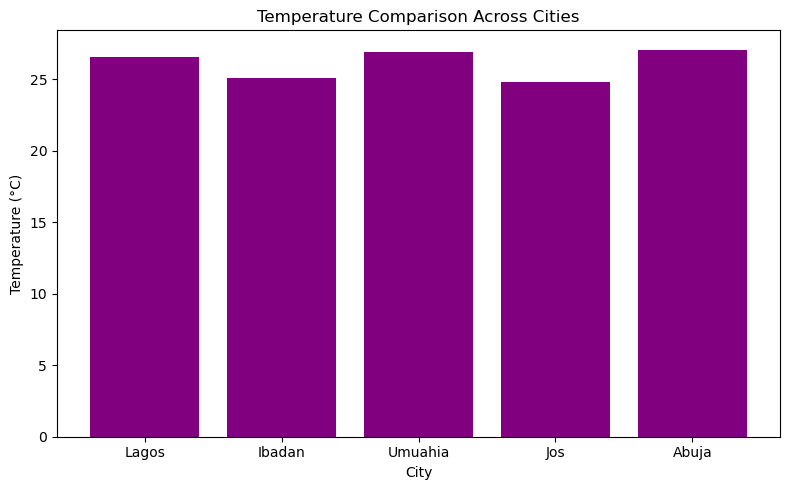

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(df["city"], df["temperature_c"], color="purple")
plt.title("Temperature Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

## Visualization 2: Humidity Comparison Chart

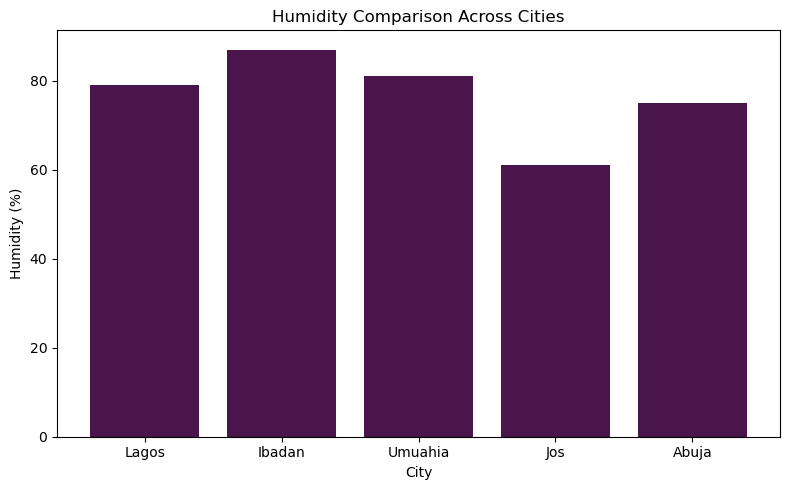

In [33]:
plt.figure(figsize=(8, 5))
plt.bar(df["city"], df["humidity_pct"], color="#4A154B")
plt.title("Humidity Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Humidity (%)")
plt.tight_layout()
plt.show()

## Visualization 3: Wind Speed Comparison Chart

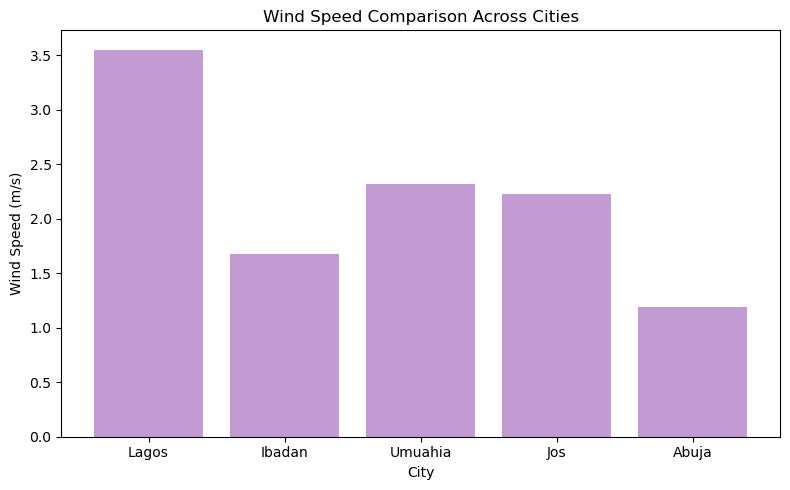

In [34]:
plt.figure(figsize=(8, 5))
plt.bar(df["city"], df["wind_speed_mps"], color="#C39BD3")
plt.title("Wind Speed Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Wind Speed (m/s)")
plt.tight_layout()
plt.show()

## Visualization 4: Weather Condition Chart Across Cities

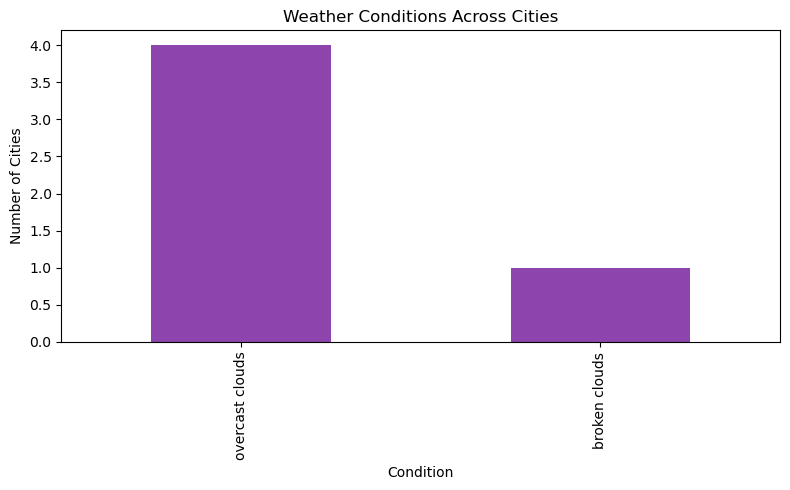

In [35]:
plt.figure(figsize=(8, 5))
df["condition"].value_counts().plot(kind="bar", color="#8E44AD")
plt.title("Weather Conditions Across Cities")
plt.xlabel("Condition")
plt.ylabel("Number of Cities")
plt.tight_layout()
plt.show()

### Visualization Summary

The bar charts above provide a clear visual comparison of temperature, humidity, and wind speed across the five cities. This makes it easier to spot patterns at a glance; for example, which city is warmest, which is most humid, and how wind conditions vary, complementing the numerical analysis performed earlier.

## Key Findings

- **Abuja** recorded the highest temperature at **27.07°C**, while **Jos** recorded the lowest at **24.82°C**.
- **Ibadan** had the highest humidity level at **87%**, indicating the most humid conditions among the selected cities.
- **Lagos** experienced the highest wind speed at **3.55 m/s**, while **Abuja** recorded the lowest at **1.19 m/s**.
- **Overcast clouds** were the dominant weather condition, observed in four out of five cities, while **Jos** experienced **broken clouds** instead.
- Across all five cities, the average temperature was **26.09°C** and average humidity was **76.60%**, reflecting generally warm and humid conditions consistent with the current rainy season in Nigeria.

## Final Summary

This project successfully demonstrated a complete ETL (Extract, Transform, Load) pipeline built around real-time weather data from the OpenWeather API. Data was extracted for five Nigerian cities (Lagos, Ibadan, Umuahia, Jos, and Abuja), cleaned and structured using Pandas, and stored in three formats (CSV, Excel, and SQLite) for flexible future use.

The resulting analysis revealed meaningful variation in temperature, humidity, and wind speed across cities, despite an overall shared pattern of warm, overcast weather typical of the season. Visualizing these differences through bar charts made the comparisons easy to interpret at a glance.

Beyond the specific weather insights, this project reinforced practical, transferable skills: connecting to a live external API, handling and cleaning nested JSON data, structuring it for analysis, and choosing appropriate storage formats. The same core workflow data analysts rely on daily when working with real-world data.